In [2]:
# ============================================================
# EDA Cellule 1 — Structure du dataset et chargement CSV
# ============================================================
import os
import pandas as pd
from pathlib import Path

DATA_ROOT = Path('/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset')

# ── 1. Arborescence ──────────────────────────────────────────
print("=== Structure du dataset ===\n")
for item in sorted(DATA_ROOT.iterdir()):
    if item.is_dir():
        files = list(item.iterdir())
        # Sous-dossiers
        subdirs = [f for f in files if f.is_dir()]
        topfiles = [f for f in files if f.is_file()][:3]
        print(f"📁 {item.name}/")
        for sd in subdirs:
            n = len(list(sd.iterdir()))
            print(f"   📁 {sd.name}/  ({n} fichiers)")
        for tf in topfiles:
            print(f"   📄 {tf.name}")
        if len([f for f in files if f.is_file()]) > 3:
            print(f"   ... ({len([f for f in files if f.is_file()])} fichiers total)")
    else:
        print(f"📄 {item.name}")

# ── 2. Chargement CSV ─────────────────────────────────────────
print("\n=== Train_metadata.csv ===\n")
train_csv = DATA_ROOT / 'stage2_train_metadata.csv'
test_csv  = DATA_ROOT / 'stage2_test_metadata.csv'

df_train = pd.read_csv(train_csv)
df_test  = pd.read_csv(test_csv)

print(f"Shape train CSV : {df_train.shape}")
print(f"Shape test CSV  : {df_test.shape}")
print(f"\nColonnes train  : {df_train.columns.tolist()}")
print(f"Colonnes test   : {df_test.columns.tolist()}")

print("\n--- 5 premières lignes train ---")
print(df_train.head())

print("\n--- Types & nulls ---")
print(df_train.dtypes)
print(f"\nValeurs nulles par colonne :\n{df_train.isnull().sum()}")

=== Structure du dataset ===

📁 Test/
   📄 1b66ef47-b795-418f-bc18-1339bc980b8b.png
   📄 1f69bd0a-8e25-4c4e-b5be-f4395f032f58.png
   📄 29d959bb-171d-487d-87b3-8637e30ba480.png
   ... (3000 fichiers total)
📁 Training/
   📁 Images/  (26684 fichiers)
   📁 Masks/  (26684 fichiers)
📄 stage2_test_metadata.csv
📄 stage2_train_metadata.csv

=== Train_metadata.csv ===

Shape train CSV : (30227, 11)
Shape test CSV  : (3000, 6)

Colonnes train  : ['patientId', 'x', 'y', 'width', 'height', 'Target', 'class', 'age', 'sex', 'modality', 'position']
Colonnes test   : ['patientId', 'PredictionString', 'age', 'sex', 'modality', 'position']

--- 5 premières lignes train ---
                              patientId      x      y  width  height  Target  \
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0   
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0   
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN       0   
3  003d8fa0-6bf1-

=== CSV brut ===
Lignes totales          : 30227
patientId uniques       : 26684
Lignes dupliquées (même patientId) : 3543

=== Distribution colonne 'class' (CSV brut) ===
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64

Total : 30227

=== Distribution colonne 'Target' (CSV brut) ===
Target
0    20672
1     9555
Name: count, dtype: int64
  0 (No Pneumonia) : 20672
  1 (Pneumonia)    : 9555

=== Après déduplication (1 ligne par patient) ===
Patients totaux  : 26684
  Target=0       : 20672
  Target=1       : 6012

Distribution 'classe' après dédup :
classe
No Lung Opacity / Not Normal    11821
Normal                           8851
Lung Opacity                     6012
Name: count, dtype: int64

=== Cohérence Target ↔ class (après dédup) ===
classe  Lung Opacity  No Lung Opacity / Not Normal  Normal
Target                                                    
0                  0              

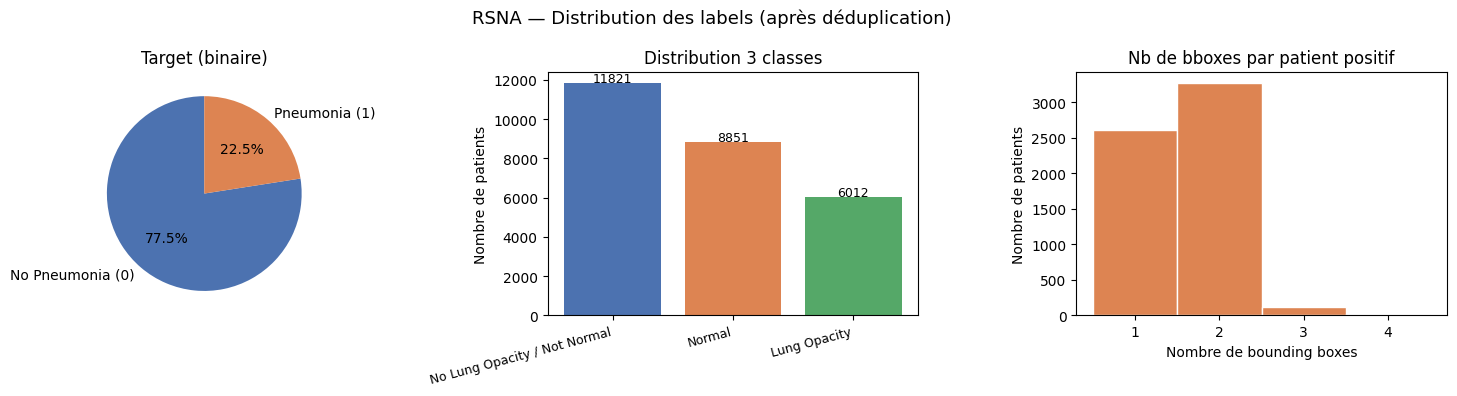


✓ EDA Cellule 2 terminée


In [3]:
# ============================================================
# EDA Cellule 2 — Distribution des labels & déduplication
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

DATA_ROOT = Path('/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset')
df_train  = pd.read_csv(DATA_ROOT / 'stage2_train_metadata.csv')

# ── 1. CSV brut : lignes vs patients uniques ──────────────────
print("=== CSV brut ===")
print(f"Lignes totales          : {len(df_train)}")
print(f"patientId uniques       : {df_train['patientId'].nunique()}")
print(f"Lignes dupliquées (même patientId) : {len(df_train) - df_train['patientId'].nunique()}")

# ── 2. Distribution colonne 'class' (brut) ───────────────────
print("\n=== Distribution colonne 'class' (CSV brut) ===")
class_counts = df_train['class'].value_counts()
print(class_counts)
print(f"\nTotal : {class_counts.sum()}")

# ── 3. Distribution colonne 'Target' (brut) ──────────────────
print("\n=== Distribution colonne 'Target' (CSV brut) ===")
target_counts = df_train['Target'].value_counts()
print(target_counts)
print(f"  0 (No Pneumonia) : {target_counts.get(0,0)}")
print(f"  1 (Pneumonia)    : {target_counts.get(1,0)}")

# ── 4. Déduplication par patientId ───────────────────────────
# Règle : label = max(Target) par patient
# Si au moins une ligne dit 1 → patient positif
# Métadonnées : prendre la première occurrence
df_dedup = df_train.groupby('patientId').agg(
    Target   = ('Target', 'max'),
    classe   = ('class',  'first'),
    age      = ('age',    'first'),
    sex      = ('sex',    'first'),
    position = ('position','first'),
    n_boxes  = ('x',      'count')   # nb de bboxes par patient
).reset_index()

print("\n=== Après déduplication (1 ligne par patient) ===")
print(f"Patients totaux  : {len(df_dedup)}")
print(f"  Target=0       : {(df_dedup['Target']==0).sum()}")
print(f"  Target=1       : {(df_dedup['Target']==1).sum()}")
print(f"\nDistribution 'classe' après dédup :")
print(df_dedup['classe'].value_counts())

# ── 5. Cohérence Target ↔ class ──────────────────────────────
print("\n=== Cohérence Target ↔ class (après dédup) ===")
cross = pd.crosstab(df_dedup['Target'], df_dedup['classe'])
print(cross)

# ── 6. Patients avec plusieurs bboxes ────────────────────────
multi = df_dedup[df_dedup['n_boxes'] > 1]
print(f"\nPatients avec >1 bounding box : {len(multi)}")
print(f"  Max bboxes pour un patient  : {df_dedup['n_boxes'].max()}")
print(f"  Distribution n_boxes (positifs) :")
print(df_dedup[df_dedup['Target']==1]['n_boxes'].value_counts().sort_index())

# ── 7. Figure : distributions ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("RSNA — Distribution des labels (après déduplication)", fontsize=13)

# Pie Target
axes[0].pie(
    [( df_dedup['Target']==0).sum(), (df_dedup['Target']==1).sum()],
    labels=['No Pneumonia (0)', 'Pneumonia (1)'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90)
axes[0].set_title("Target (binaire)")

# Bar classes
class_dedup = df_dedup['classe'].value_counts()
axes[1].bar(range(len(class_dedup)), class_dedup.values,
            color=['#4C72B0','#DD8452','#55A868'])
axes[1].set_xticks(range(len(class_dedup)))
axes[1].set_xticklabels(class_dedup.index, rotation=15, ha='right', fontsize=9)
axes[1].set_title("Distribution 3 classes")
axes[1].set_ylabel("Nombre de patients")
for i, v in enumerate(class_dedup.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=9)

# Hist n_boxes pour les positifs
pos_boxes = df_dedup[df_dedup['Target']==1]['n_boxes']
axes[2].hist(pos_boxes, bins=range(1, pos_boxes.max()+2),
             align='left', color='#DD8452', edgecolor='white')
axes[2].set_title("Nb de bboxes par patient positif")
axes[2].set_xlabel("Nombre de bounding boxes")
axes[2].set_ylabel("Nombre de patients")

plt.tight_layout()
plt.show()

print("\n✓ EDA Cellule 2 terminée")

=== Vérification résolution (10 images aléatoires) ===
  ce6a770b...  (1024, 1024)  mode=L
  37c401dc...  (1024, 1024)  mode=L
  0a9c4c04...  (1024, 1024)  mode=L
  eb9bf555...  (1024, 1024)  mode=L
  661f42bd...  (1024, 1024)  mode=L
  5dc11277...  (1024, 1024)  mode=L
  5772efe6...  (1024, 1024)  mode=L
  3f9cbb35...  (1024, 1024)  mode=L
  ea3f3fb8...  (1024, 1024)  mode=L
  35412b65...  (1024, 1024)  mode=L

Résolutions uniques : {(1024, 1024)}

=== Statistiques d'intensité (30 images, 15 pos + 15 neg) ===
  POS | mean=0.426±0.086 | std=0.232±0.031
  NEG | mean=0.484±0.086 | std=0.213±0.050


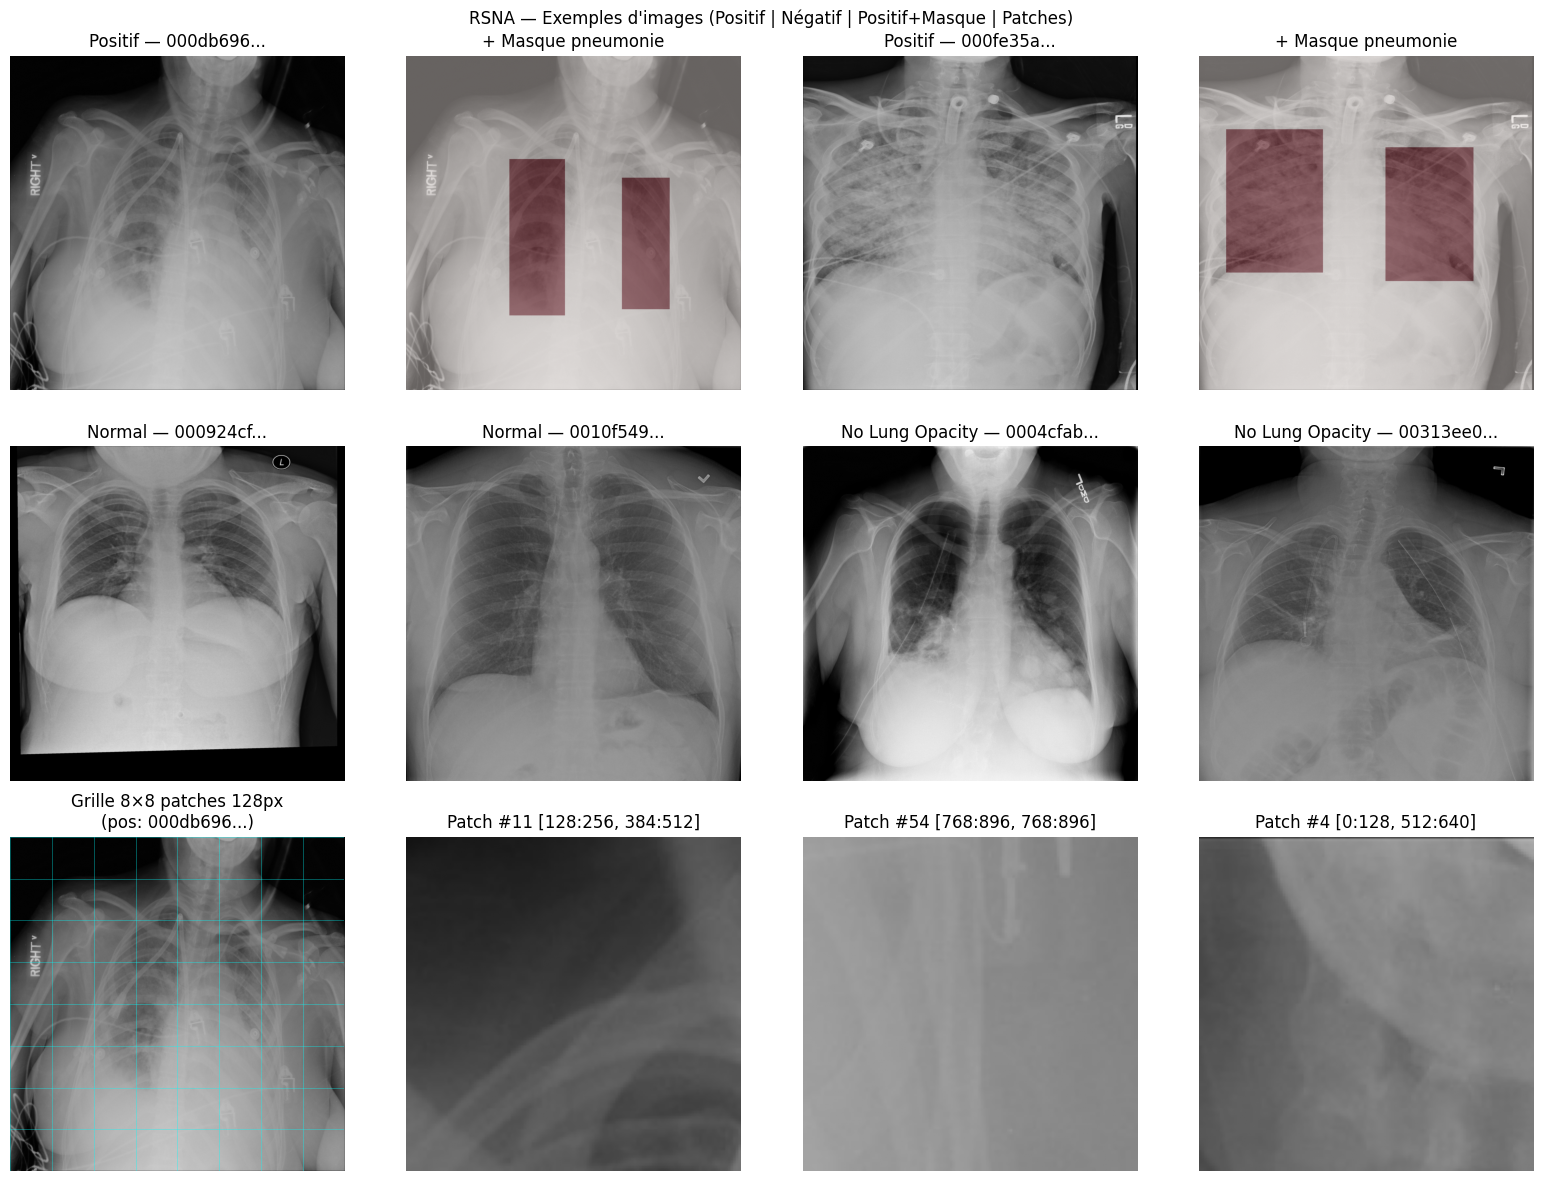


=== Vérification fichiers manquants ===
Images manquantes : 0

✓ EDA Cellule 3 terminée


In [4]:
# ============================================================
# EDA Cellule 3 — Exploration visuelle des images
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image

DATA_ROOT = Path('/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset')
IMG_DIR   = DATA_ROOT / 'Training' / 'Images'
MASK_DIR  = DATA_ROOT / 'Training' / 'Masks'

df_raw   = pd.read_csv(DATA_ROOT / 'stage2_train_metadata.csv')

# Déduplication propre (même logique que le futur Dataset)
df_dedup = df_raw.groupby('patientId').agg(
    Target   = ('Target', 'max'),
    classe   = ('class',  'first'),
    age      = ('age',    'first'),
    sex      = ('sex',    'first'),
    position = ('position', 'first')
).reset_index()

df_pos = df_dedup[df_dedup['Target'] == 1].reset_index(drop=True)
df_neg = df_dedup[df_dedup['Target'] == 0].reset_index(drop=True)

# ── 1. Résolution et format ───────────────────────────────────
print("=== Vérification résolution (10 images aléatoires) ===")
import random
random.seed(42)
sample_ids = random.sample(df_dedup['patientId'].tolist(), 10)
shapes = []
for pid in sample_ids:
    img = Image.open(IMG_DIR / f"{pid}.png")
    shapes.append(img.size)           # (width, height)
    print(f"  {pid[:8]}...  {img.size}  mode={img.mode}")

unique_shapes = set(shapes)
print(f"\nRésolutions uniques : {unique_shapes}")

# ── 2. Statistiques d'intensité ──────────────────────────────
print("\n=== Statistiques d'intensité (30 images, 15 pos + 15 neg) ===")
stats = {'pos': [], 'neg': []}
for pid in df_pos['patientId'][:15]:
    arr = np.array(Image.open(IMG_DIR / f"{pid}.png"), dtype=np.float32) / 255.0
    stats['pos'].append({'mean': arr.mean(), 'std': arr.std(),
                         'min': arr.min(), 'max': arr.max()})
for pid in df_neg['patientId'][:15]:
    arr = np.array(Image.open(IMG_DIR / f"{pid}.png"), dtype=np.float32) / 255.0
    stats['neg'].append({'mean': arr.mean(), 'std': arr.std(),
                         'min': arr.min(), 'max': arr.max()})

for label, data in stats.items():
    means = [d['mean'] for d in data]
    stds  = [d['std']  for d in data]
    print(f"  {label.upper():3s} | mean={np.mean(means):.3f}±{np.std(means):.3f} "
          f"| std={np.mean(stds):.3f}±{np.std(stds):.3f}")

# ── 3. Exemples visuels : pos / neg / masque ─────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("RSNA — Exemples d'images (Positif | Négatif | Positif+Masque | Patches)",
             fontsize=12)

# Ligne 1 : 2 positifs + leur masque
for col, pid in enumerate(df_pos['patientId'][:2]):
    img  = np.array(Image.open(IMG_DIR  / f"{pid}.png"), dtype=np.float32) / 255.0
    mask = np.array(Image.open(MASK_DIR / f"{pid}.png"), dtype=np.float32) / 255.0

    axes[0, col*2].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0, col*2].set_title(f"Positif — {pid[:8]}...")
    axes[0, col*2].axis('off')

    axes[0, col*2+1].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0, col*2+1].imshow(mask, cmap='Reds', alpha=0.4, vmin=0, vmax=1)
    axes[0, col*2+1].set_title("+ Masque pneumonie")
    axes[0, col*2+1].axis('off')

# Ligne 2 : 2 Normal + 2 No Lung Opacity/Not Normal
neg_normal  = df_dedup[df_dedup['classe']=='Normal']['patientId'].iloc[:2].tolist()
neg_notNorm = df_dedup[df_dedup['classe']=='No Lung Opacity / Not Normal']['patientId'].iloc[:2].tolist()

for col, pid in enumerate(neg_normal):
    arr = np.array(Image.open(IMG_DIR / f"{pid}.png"), dtype=np.float32) / 255.0
    axes[1, col].imshow(arr, cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f"Normal — {pid[:8]}...")
    axes[1, col].axis('off')

for col, pid in enumerate(neg_notNorm):
    arr = np.array(Image.open(IMG_DIR / f"{pid}.png"), dtype=np.float32) / 255.0
    axes[1, col+2].imshow(arr, cmap='gray', vmin=0, vmax=1)
    axes[1, col+2].set_title(f"No Lung Opacity — {pid[:8]}...")
    axes[1, col+2].axis('off')

# Ligne 3 : découpage en patches 128×128 sur 1 image positive
pid_demo = df_pos['patientId'].iloc[0]
img_demo = np.array(Image.open(IMG_DIR / f"{pid_demo}.png"), dtype=np.float32) / 255.0

# Afficher image entière avec grille patches
axes[2, 0].imshow(img_demo, cmap='gray', vmin=0, vmax=1)
ps = 128
for r in range(0, 1024, ps):
    axes[2, 0].axhline(r, color='cyan', linewidth=0.4, alpha=0.6)
for c in range(0, 1024, ps):
    axes[2, 0].axvline(c, color='cyan', linewidth=0.4, alpha=0.6)
axes[2, 0].set_title(f"Grille 8×8 patches 128px\n(pos: {pid_demo[:8]}...)")
axes[2, 0].axis('off')

# 3 patches aléatoires de cette image
patches_idx = random.sample(range(64), 3)
for k, pidx in enumerate(patches_idx):
    r = (pidx // 8) * ps
    c = (pidx %  8) * ps
    patch = img_demo[r:r+ps, c:c+ps]
    axes[2, k+1].imshow(patch, cmap='gray', vmin=0, vmax=1)
    axes[2, k+1].set_title(f"Patch #{pidx} [{r}:{r+ps}, {c}:{c+ps}]")
    axes[2, k+1].axis('off')

plt.tight_layout()
plt.show()

# ── 4. Vérification fichiers manquants ───────────────────────
print("\n=== Vérification fichiers manquants ===")
missing = []
for pid in df_dedup['patientId']:
    if not (IMG_DIR / f"{pid}.png").exists():
        missing.append(pid)
print(f"Images manquantes : {len(missing)}")
if missing:
    print(f"  Exemples : {missing[:5]}")

print("\n✓ EDA Cellule 3 terminée")